In [ ]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import  LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.datasets import load_breast_cancer

In [ ]:
#Performance metrics of classification problem:
#1) confusion Matrix : Matrix having 4 values in it
#TP   FN
#FP   TN
#TP --> true positive
#TN -->  true negative
#FP -->  false positive
#FN -->  false negative

#weather dataset
#temp   type    humidity   Actual  predicted
# 35     cloudy    23.5       0        0 -----> TN
#  -        -       -         1        0 -----> FN
#  -        -       -         0        1 -----> FP
#  -        -       -         1        1 -----> TP
#  -        -       -         1        0 -----> FN
#  -        -       -         0        0 -----> TN

# confusion matrix count of true positive , true negative , false positive and false negative
#1    2
#1    2
#always TP&TN count should be more than FN- 50% dangerous and FN - dangerous



In [ ]:
#2. accuracy: total true positives among all cases
   #accuracy = TP / (TP + TN + FP + FN) -formula tp by all cases
#3. precision: focuses more on prediction part . among all positive cases how many r correct
   #precision : TP/TP+FP
#4. recall = tp/tp+fn
#5. f-1 score : gives equal importance for both tp and tn
#f-1 score = 2*((precision*recall)/(precision +recall))

In [ ]:
data = load_breast_cancer()
x = data.data
y = data.target

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(f"Shape of x_train: {x_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of x_test: {x_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of x_train: (455, 30)
Shape of y_train: (455,)
Shape of x_test: (114, 30)
Shape of y_test: (114,)


In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [ ]:
confusion_matrix()

In [ ]:
#check if its over fitting or underfitting
train then chec fitting


In [12]:
df = pd.read_csv("/content/heart.csv")
df.head()

,Unnamed: 0,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [15]:
missing_values = df.isnull().sum()
print(missing_values)

Unnamed: 0    0
age           0
sex           0
cp            0
trestbps      0
chol          0
fbs           0
restecg       0
thalach       0
exang         0
oldpeak       0
slope         0
ca            0
thal          0
target        0
dtype: int64


In [ ]:
#checking wether female or male r having more heart diseases


# Task
Analyze and visualize the distribution of heart disease by gender using the `df` DataFrame, then summarize the findings, assuming 'sex' represents gender (e.g., 0 for female, 1 for male) and 'target' indicates heart disease presence (e.g., 0 for no disease, 1 for disease).

## Analyze Heart Disease by Gender

### Subtask:
Group the `df` DataFrame by 'sex' and 'target' columns to count the number of males and females with and without heart disease. The 'sex' column likely represents gender (e.g., 0 for female, 1 for male) and 'target' indicates heart disease presence (e.g., 0 for no disease, 1 for disease).


**Reasoning**:
I will group the `df` DataFrame by 'sex' and 'target' columns and count the occurrences for each group to analyze heart disease by gender.



In [16]:
heart_disease_by_gender = df.groupby(['sex', 'target']).size().unstack(fill_value=0)
print(heart_disease_by_gender)

target    0   1
sex            
0        24  72
1       114  93


**Reasoning**:
I will visualize the `heart_disease_by_gender` DataFrame using a bar plot to clearly show the distribution of heart disease by gender. This will help in understanding the relationship between gender and heart disease presence.



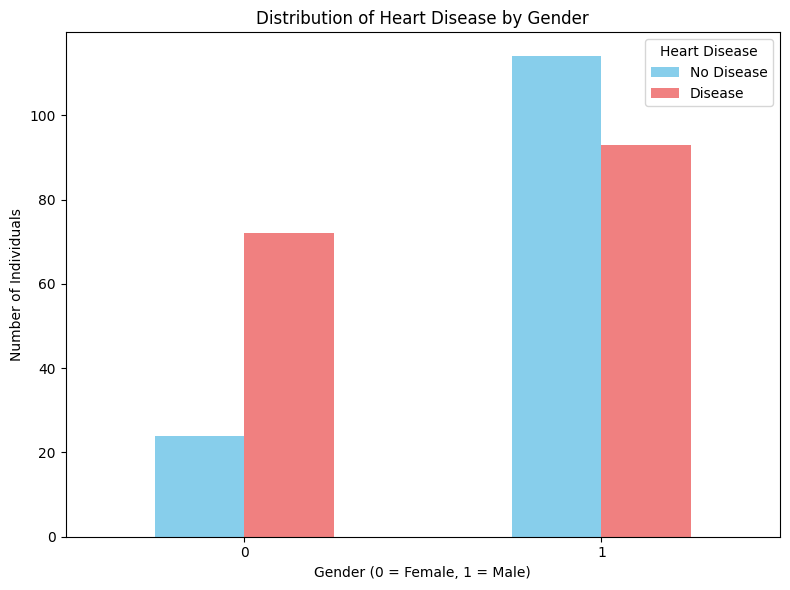

In [17]:
heart_disease_by_gender.plot(kind='bar', figsize=(8, 6), color=['skyblue', 'lightcoral'])
plt.title('Distribution of Heart Disease by Gender')
plt.xlabel('Gender (0 = Female, 1 = Male)')
plt.ylabel('Number of Individuals')
plt.xticks(rotation=0)
plt.legend(title='Heart Disease', labels=['No Disease', 'Disease'])
plt.tight_layout()
plt.show()


In [ ]:
#training the model - logistic regression:


In [18]:
y_pred = model.predict(x_test)
print(y_pred)

[1 0 0 1 1 0 0 0 1 1 1 0 1 0 1 0 1 1 1 0 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0
 1 0 1 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 1 1 1 0 0 1 1 1 0 0 1 1 0 0 1 0
 1 1 1 1 1 1 0 1 1 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 1 0 0 1 0 0 1 1 1 0 1 1 0
 1 0 0]


In [19]:
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[39  4]
 [ 1 70]]


In [20]:
print('Classification Report:')
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.91      0.94        43
           1       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [ ]:
#which age group is having heart disease:


# Task
Analyze and visualize the distribution of heart disease by age group using the `df` DataFrame, then summarize the key findings, identifying which age groups show a higher or lower incidence of heart disease.

## Analyze Heart Disease by Age Group


Group the `df` DataFrame by 'age' and 'target' (heart disease presence) to count the number of individuals with and without heart disease within each age group.


In [21]:
heart_disease_by_age = df.groupby(['age', 'target']).size().unstack(fill_value=0)
print(heart_disease_by_age)

target   0   1
age           
29       0   1
34       0   2
35       2   2
37       0   2
38       1   2
39       1   3
40       2   1
41       1   9
42       1   7
43       3   5
44       3   8
45       2   6
46       3   4
47       2   3
48       3   4
49       2   3
50       3   4
51       3   9
52       4   9
53       2   6
54       6  10
55       5   3
56       6   5
57      10   7
58      12   7
59       9   5
60       8   3
61       7   1
62       7   4
63       6   3
64       4   6
65       4   4
66       3   4
67       6   3
68       2   2
69       1   2
70       3   1
71       0   3
74       0   1
76       0   1
77       1   0


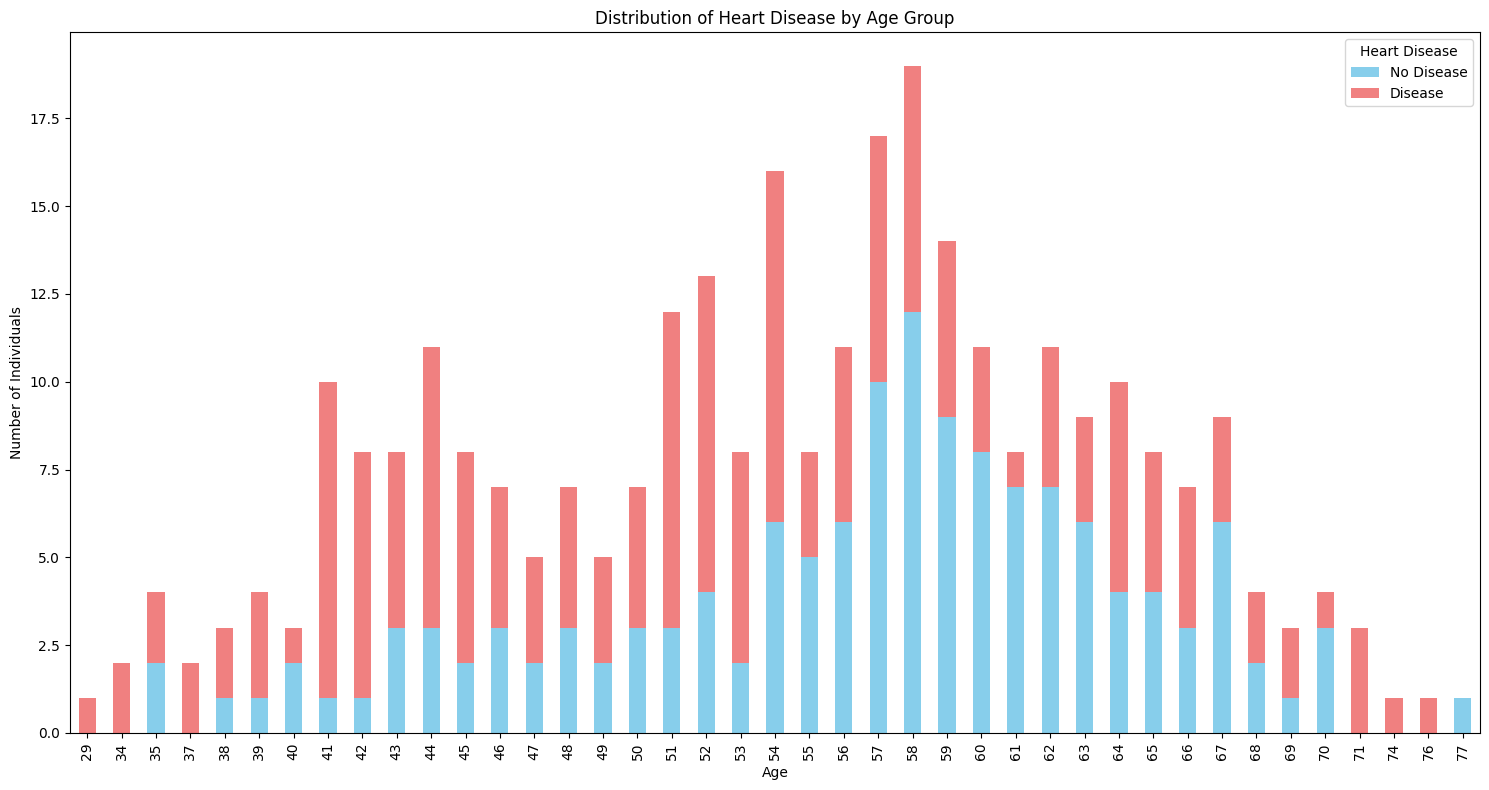

In [22]:
heart_disease_by_age.plot(kind='bar', stacked=True, figsize=(15, 8), color=['skyblue', 'lightcoral'])
plt.title('Distribution of Heart Disease by Age Group')
plt.xlabel('Age')
plt.ylabel('Number of Individuals')
plt.legend(title='Heart Disease', labels=['No Disease', 'Disease'])
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()